# I) PROJECT INTRODUCTION


**In this project, we will try to solve the problem of classify a movie as positive or negative base on the review given in website IMDB. As the review happen sometimes in long text, sometimes short, sometimes user giving spelling error, or maybe writting includes special characters, lead to challenge for the user or movie critic or those who interest, to navigate such review as a positive or negative. Thus we will use this dataset of 50k reviews, labeled as positive/negative to train the model of Deep Learning using Keras library**

# II) Exploratory Data Analysis (EDA) 


**At this session let's do data inspection, looking through statistical info and several charts including cleaning or transform data <insert purpose>**

### first thing first, import tools for analysis, visuallization and modeling

In [1]:
# install necessary library for model processing
!pip install nltk
!pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1.tar.gz
!pip install --upgrade spacy
!pip install --upgrade spacy-transformers
!pip install tensorflow-text
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 455.5 kB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Using cached spacy-3.7.5-cp312-cp312-macosx_11_0_arm64.whl.metadata (27 kB)
  Using cached thinc-8.2.5-cp312-cp312-macosx_11_0_arm64.whl.metadata (15 kB)
  Using cached blis-0.7.11-cp312-cp312-macosx_11_0_arm64.whl.metadata (7.4 kB)
Using cached spacy-3.7.5-cp312-cp312-macosx_11_0_arm64.whl (6.1 MB)
Using cached thinc-8.2.5-cp312-cp312-macosx_11_0_arm64.whl (760 kB)
Using cached blis-0.7.11-cp312-cp312-macosx_11_0_arm64.whl (1.1 MB)
  Attempting uninstall: blis
    Found existing installation: blis 1.3.3
    Uninstalling blis-1.3.3:
      Successfully uninstalled blis-1.3.3
  Attempting uninstall: thinc
    Found existing installation: thinc 8.3.10
    Uninstalling thinc-8.3.10:
      Successfully uninstalled thinc-8.3.10
  Attempting uninstall: spacy
    Found existing installation: spacy 3.8.11
    Uninstalling spacy-3.8.11:
      Successfully uninstal

In [2]:
#import necessary library
import pandas as pd
import numpy as np
import os

In [36]:
pd.options.display.max_columns
pd.options.display.max_rows
import os, math
 
#for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
 
#for text cleaning / preprocessing
import string, re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import re
import torch
from typing import List
import requests
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import spacy
from bs4 import BeautifulSoup
import keras_hub
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import spacy
 
#for data analysis and modeling
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn import decomposition
 
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

[nltk_data] Downloading package punkt to /Users/Gaby/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/Gaby/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 1. explore dataset


In [4]:
path_train = 'IMDB Dataset.csv'
data = pd.read_csv(path_train)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
#let's have a look on data
pd.set_option('display.max_colwidth', None)
data.head()

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zom

in this dataset we have 50k records, which will be splitted into training, validation and test set.
before splitting, we will do some data cleaning so that later we do not need to repeat the cleaning step on validation & test

In [6]:
#copy data into new dataframe for processing, this step will help to reduce the time importing data overagain if any error during data cleaning.
df = data.copy()
df['sentiment'].value_counts(normalize = True)

sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

we see the split is equal 50/50, so dataset is well balanced between positive/negative class.
for training convenience we will add 1 column class with positive = 1 and negative = 0.

In [7]:
df['class'] = df['sentiment'].map({'positive': 1, 'negative': 0})

check if data shown as expected:

In [8]:
pd.set_option('display.max_colwidth', None)
pd.concat([df[df['class'] == 1].head(), 
           df[df['class'] == 0].tail()
          ])

,review,sentiment,class
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive,1
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive,1
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive,1
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what money, power and success do to people 

### 2. Data inspection

Now let's inspect the text to see what is best strategy for this problem.

In [9]:
# check the max - min length of Text to understand data complexity for training
df['text_length'] = df['review'].apply(len)
df.groupby('class')['text_length'].agg(['min', 'max', 'mean'])

,min,max,mean
class,,,
0,32,8969,1294.06436
1,65,13704,1324.79768


here we have little different, on negative review seem people giving less words compare to positive, as the min of positive review is double negative and average length of review also 5% longer.

**visuallize data to observe distribution, complexity of review/text length/concentration point,ect.**

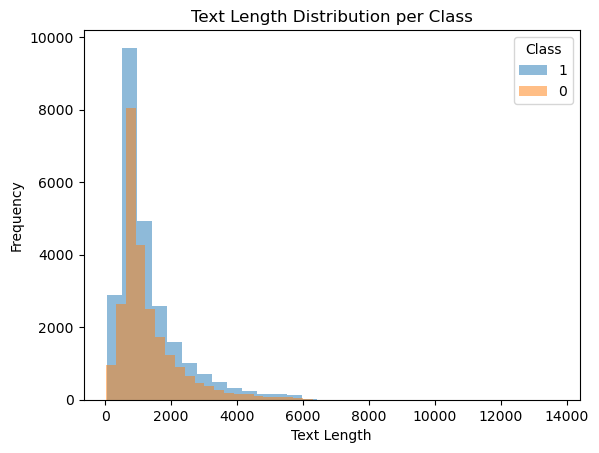

In [10]:
for label in df['class'].unique():
    subset = df[df['class'] == label]
    plt.hist(subset['text_length'], bins=30, alpha=0.5, label=str(label))

plt.title('Text Length Distribution per Class')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend(title='Class')


as above we already knew that data is balanced, thus here we see following points:
1) it's visible that positive review have more words than negative
2) both highly concentrate at 900 - 1200 words

small number falling out of 6000 length, let's have a look on them

In [11]:
df[df['text_length'] >= 6000]['text_length'].describe()

count       69.000000
mean      7172.492754
std       1822.567264
min       6002.000000
25%       6102.000000
50%       6295.000000
75%       7268.000000
max      13704.000000
Name: text_length, dtype: float64

In [12]:
df[df['text_length'] >= 6000]['class'].value_counts()

class
1    46
0    23
Name: count, dtype: int64

still consistent with what we observed earlier, that positive review still double negative review on long review

### 3. Text vectorization process and decomposition methodology
now we need to decompose the text to count word's frequency in each text

In [13]:
#clean text:
#define stop words for across analysis, data cleaning & modeling:
#clean text with update set of stopwords:

sw1 = ["a","a's", 'made','make', 'makes','story','making','actor','actress','acting','actors','role','end','ending','time','main','watching','show','simply','people','character','characters',"film",'films','movie','movies',"able","about","above","according","http","https","accordingly","across","actually","after","afterwards","again","against","ain't","all","allow","allows","almost","alone","along","already","also","although","always","am","among","amongst","an","and","another","any","anybody","anyhow","anyone","anything","anyway","anyways","anywhere","apart","appear","appreciate","appropriate","are","aren't","around","as","aside","ask","asking","associated","at","available","away","awfully","b","be","became","because","become","becomes","becoming","been","before","beforehand","behind","being","believe","below","beside","besides","best","better","between","beyond","both","brief","but","by","c","c'mon","c's","came","can","can't","cannot","cant","cause","causes","certain","certainly","changes","clearly","co","com","come","comes","concerning","consequently","consider","considering","contain","containing","contains","corresponding","could","couldn't","course","currently","d","definitely","described","despite","did","didn't","different","do","does","doesn't","doing","don't","done","down","downwards","during","e","each","edu","eg","eight","either","else","elsewhere","enough","entirely","especially","et","etc","even","ever","every","everybody","everyone","everything","everywhere","ex","exactly","example","except","f","far","few","fifth","first","five","followed","following","follows","for","former","formerly","forth","four","from","further","furthermore","g","get","gets","getting","given","gives","go","goes","going","gone","got","gotten","greetings","h","had","hadn't","happens","hardly","has","hasn't","have","haven't","having","he","he's","hello","help","hence","her","here","here's","hereafter","hereby","herein","hereupon","hers","herself","hi","him","himself","his","hither","hopefully","how","howbeit","however","i","i'd","i'll","i'm","i've","ie","if","ignored","immediate","in","inasmuch","inc","indeed","indicate","indicated","indicates","inner","insofar","instead","into","inward","is","isn't","it","it'd","it'll","it's","its","itself","j","just","k","keep","keeps","kept","know","known","knows","l","last","lately","later","latter","latterly","least","less","lest","let","let's","like","liked","likely","little","look","looking","looks","ltd","m","mainly","many","may","maybe","me","mean","meanwhile","merely","might","more","moreover","most","mostly","much","must","my","myself","n","name","namely","nd","near","nearly","necessary","need","needs","neither","never","nevertheless","new","next","nine","no","nobody","non","none","noone","nor","normally","not","nothing","novel","now","nowhere","o","obviously","of","off","often","oh","ok","okay","old","on","once","one","ones","only","onto","or","other","others","otherwise","ought","our","ours","ourselves","out","outside","over","overall","own","p","particular","particularly","per","perhaps","placed","please","plus","possible","presumably","probably","provides","q","que","quite","qv","r","rather","rd","re","really","reasonably","regarding","regardless","regards","relatively","respectively","right","s","said","same","saw","say","saying","says","second","secondly","see","seeing","seem","seemed","seeming","seems","seen","self","selves","sensible","sent","serious","seriously","seven","several","shall","she","should","shouldn't","since","six","so","some","somebody","somehow","someone","something","sometime","sometimes","somewhat","somewhere","soon","sorry","specified","specify","specifying","still","sub","such","sup","sure","t","t's","take","taken","tell","tends","th","than","thank","thanks","thanx","that","that's","thats","the","their","theirs","them","themselves","then","thence","there","there's","thereafter","thereby","therefore","therein","theres","thereupon","these","they","they'd","they'll","they're","they've","think","third","this","thorough","thoroughly","those","though","three","through","throughout","thru","thus","to","together","too","took","toward","towards","tried","tries","truly","try","trying","twice","two","u","un","under","unfortunately","unless","unlikely","until","unto","up","upon","us","use","used","useful","uses","using","usually","uucp","v","value","various","very","via","viz","vs","w","want","wants","was","wasn't","way","we","we'd","we'll","we're","we've","welcome","well","went","were","weren't","what","what's","whatever","when","whence","whenever","where","where's","whereafter","whereas","whereby","wherein","whereupon","wherever","whether","which","while","whither","who","who's","whoever","whole","whom","whose","why","will","willing","wish","with","within","without","won't","wonder","would","wouldn't","x","y","yes","yet","you","you'd","you'll","you're","you've","your","yours","yourself","yourselves","z","zero"]
sw1 = set(sw1)
sw = stopwords.words("english")
sw = set(sw)
stop_words = set.union(sw1, sw)

def clean_text(txt):
     
    #process numbers / money
    txt = txt.lower() # lowercase
    txt = txt.replace("<br /><br />", "") #remove html mark
    txt = re.sub('\W+', ' ', txt) #remove special character/punctuation (non-letter, non-digit)
    txt = txt.replace(" n ", "") #remove the brief of AND in both type of news
    # txt = txt.replace("co", "") #remove the text in cited website appear in both type of news 
    # txt = txt.replace("ad", "") #manual update on special case
    # txt = txt.replace("amp", "") #merge
    txt = re.sub(r"http\S+", "", txt)  # Remove URLs
    txt = re.sub(r"<.*?>", "", txt)    # Remove HTML tags
    txt = re.sub(r"[%s]" % re.escape(string.punctuation), "", txt)  # Remove punctuation
    txt = re.sub(r"\n", " ", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    txt = re.sub('\s+', ' ', txt)   #s ~ space

    words = [w for w in word_tokenize(txt) if not w in stop_words] #gather all words in text that not stopwords
    words = [word for word in words if word.isalpha()]
    
    cleaned_text = ' '.join(words)
    return cleaned_text

In [14]:
#see distribution of repeated words in actual disaster
text_clean_1 = clean_text(str(df[df['class']==1]['review'].values.tolist()))
wordcloud = WordCloud(
                    width = 600, height = 300, random_state=42, background_color='black', colormap='Set3', collocations=False, normalize_plurals = False
                    ).generate(text_clean_1)

print(f'positive review {len(wordcloud.words_)}')
print(f'words statistic in positive review: {wordcloud.words_}')

positive review 200
words statistic in positive review: {'good': 1.0, 'great': 0.8629161118508655, 'love': 0.5783621837549934, 'life': 0.5416777629826898, 'man': 0.44986684420772305, 'watch': 0.4477363515312916, 'years': 0.3579893475366178, 'scene': 0.3445406125166445, 'real': 0.3403462050599201, 'back': 0.33155792276964047, 'scenes': 0.3248335552596538, 'plot': 0.3175765645805593, 'world': 0.31637816245006656, 'young': 0.2978029294274301, 'work': 0.2978029294274301, 'find': 0.29733688415446075, 'lot': 0.28342210386151795, 'cast': 0.27496671105193077, 'funny': 0.2737017310252996, 'series': 0.27010652463382157, 'part': 0.26944074567243675, 'director': 0.26591211717709723, 'music': 0.2603861517976032, 'bad': 0.24940079893475367, 'family': 0.24587217043941412, 'performance': 0.2444074567243675, 'things': 0.24254327563249, 'comedy': 0.2374167776298269, 'times': 0.23721704394141147, 'big': 0.233422103861518, 'long': 0.22916111850865512, 'thing': 0.225965379494008, 'excellent': 0.22323568575

In [15]:
#see distribution of repeated words in non disaster
text_clean_0 = clean_text(str(df[df['class']==0]['review'].values.tolist()))
wordcloud = WordCloud(
                    width = 600, height = 300, random_state=42, background_color='black', colormap='Set3', collocations=False, normalize_plurals = False
                    ).generate(text_clean_0)

print(f'negative review {len(wordcloud.words_)}')
print(f'words statistic in negative review: {wordcloud.words_}')

negative review 200
words statistic in negative review: {'good': 1.0, 'bad': 0.9997282054766596, 'plot': 0.5575185160019026, 'watch': 0.4901814228443297, 'scene': 0.3930148807501529, 'thing': 0.39253924033430726, 'scenes': 0.38003669226065095, 'great': 0.35156621594074877, 'man': 0.344023917918054, 'worst': 0.33199701026024325, 'director': 0.32662906842427125, 'life': 0.3245906094992186, 'back': 0.3189508731399062, 'funny': 0.3155534415981518, 'love': 0.2933342393150778, 'real': 0.2931303934225725, 'minutes': 0.29115988312835495, 'pretty': 0.28932527009580755, 'horror': 0.2855201467690426, 'script': 0.2779099001155127, 'guy': 0.27736631106883197, 'work': 0.276618876129646, 'lot': 0.25997146157504925, 'part': 0.25990351294421415, 'find': 0.2549432628932527, 'things': 0.25086634504314737, 'original': 0.2506624991506421, 'fact': 0.2504586532581369, 'give': 0.24943942379561052, 'thought': 0.2489637833797649, 'point': 0.24359584154379288, 'big': 0.2344227763810559, 'long': 0.233539444180199

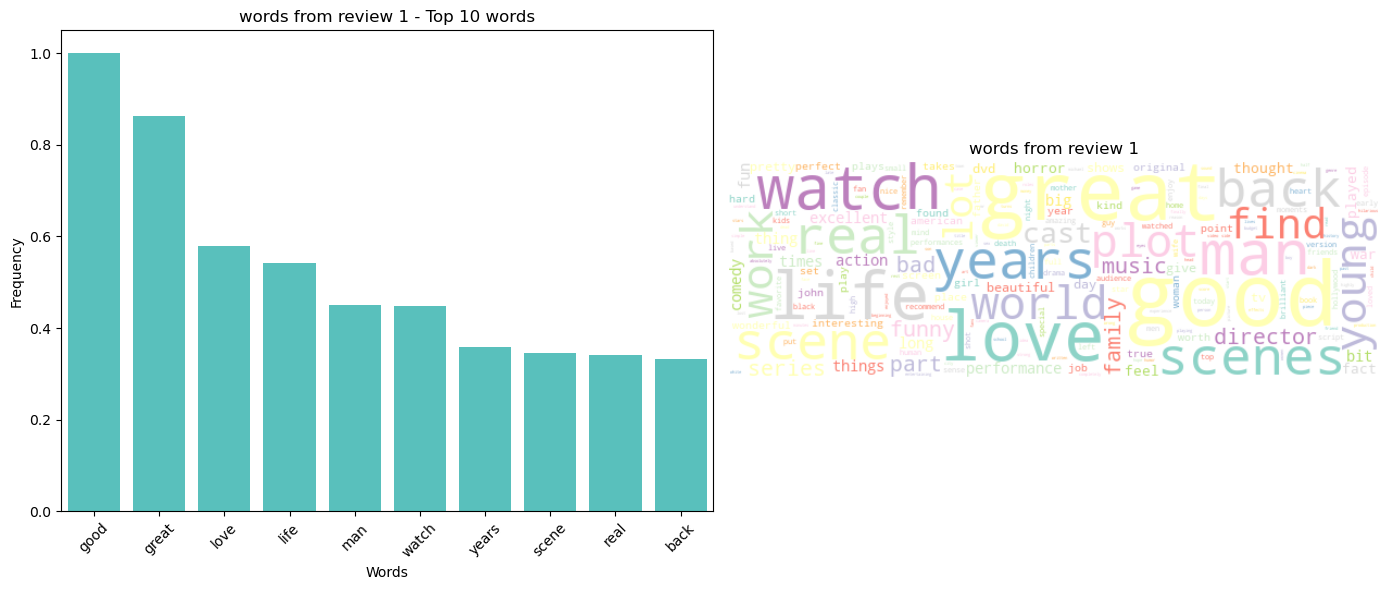

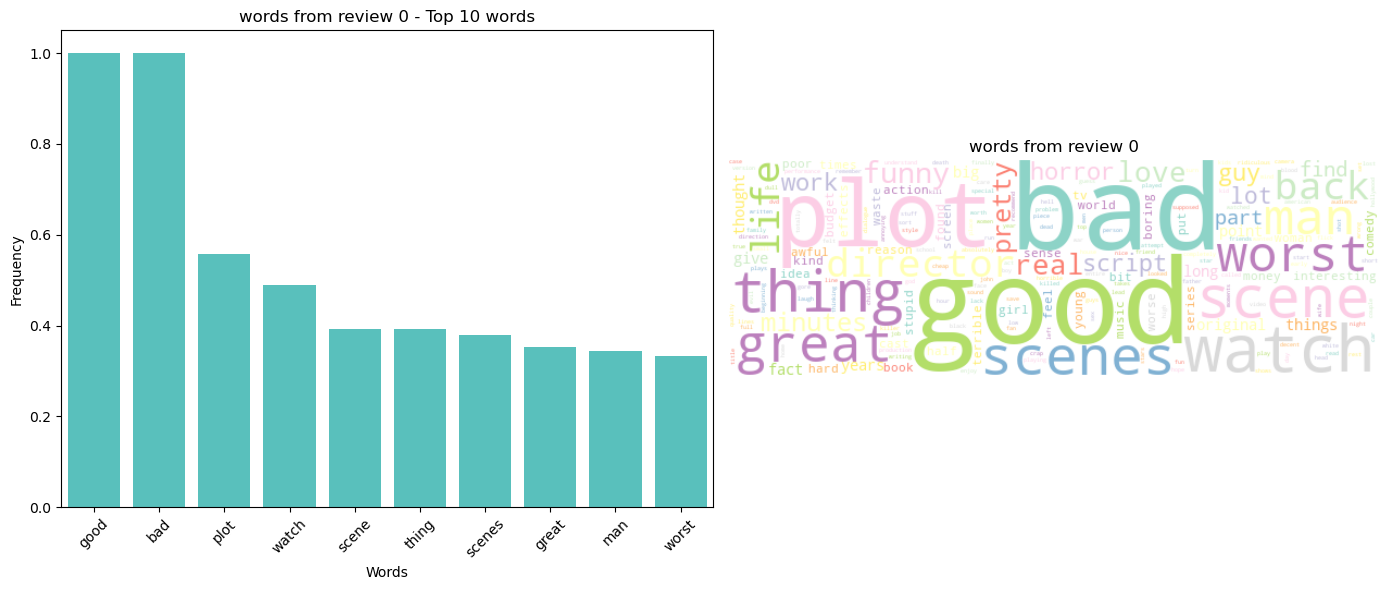

In [16]:
def plot_wordcloud_(text, title, n=10):
    # Create and Generate a Word Cloud Image
    wordcloud = WordCloud(
        width=600, height=200, random_state=42,
        background_color='white', colormap='Set3',
        collocations=False, normalize_plurals=False
    ).generate(text)

    top_words = pd.DataFrame(wordcloud.words_.items()).head(n)
    top_words.columns = ['word', 'freq']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.barplot(x='word', y='freq', data=top_words, color='mediumturquoise', ax=axes[0])
    axes[0].set(xlabel='Words', ylabel='Frequency', title=f'{title} - Top {n} words')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].imshow(wordcloud, interpolation='bilinear')
    axes[1].set_title(title, size=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

for label in df['class'].unique():
    plot_wordcloud_(clean_text(str(df[df['class']==label]['review'].values.tolist())),f'words from review {label}')


in general we see different in distribution and frequency of the words in negative and positive review

### 4. Data transformation and preprocessing for training model


at this step we will use the clean text been processed above to train the model.
later, we will try different technique as spacy function to clean the raw review to evaluate which method of text pre-processing impact the model performance. 

In [17]:
# Apply only clean_text function to all reviews
df['text_clean'] = df['review'].apply(lambda x: clean_text(str(x)))

# Inspect the first few cleaned reviews
df['text_clean'].head()

0    reviewers mentioned oz episode hooked happened thing struck oz brutality unflinching scenes violence set word trust faint hearted timid pulls punches drugs sex violence hardcore classic word called oz nickname oswald maximum security state penitentary focuses emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home aryans muslims gangstas latinos christians italians irish scuffles death stares dodgy dealings shady agreements appeal due fact shows dare forget pretty pictures painted mainstream audiences forget charm forget romance oz mess episode struck nasty surreal ready watched developed taste oz accustomed high levels graphic violence violence injustice crooked guards sold nickel inmates kill order mannered middle class inmates turned prison bitches due lack street skills prison experience oz comfortable uncomfortable viewing touch darker side
1                                                                                      

In [18]:
#splitting the test/train and validation

X_temp, X_test, y_temp, y_test = train_test_split(df['text_clean'], df['class'], test_size=0.3, stratify=df['class']) #saving 15k records for testing
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp) #28k records for training and 7k for valiation

# III) Model Architecture

In this project, we will process texts to matrix form (word embedding) using TF-IDF as it helps to filter out the stopwords (commonly repeated words) to ensure the remaining words is play crucial role in deliver key message which help to classify the text better, as well as efficient in vectorizing process.

Model will be trained using BERT as the transformer architecture will be used as alternative sequential neural network model to build and train data.

### 1. Model architecture

In [19]:
#baseline model architecture
preprocessor = keras_hub.models.DistilBertPreprocessor.from_preset('distil_bert_base_en_uncased', 
                                                                   sequence_length=128)

classifier = keras_hub.models.DistilBertClassifier.from_preset('distil_bert_base_en_uncased', 
                                                               num_classes=1,
                                                               preprocessor=preprocessor)

classifier.compile(loss=BinaryCrossentropy(from_logits=True), optimizer=Adam(learning_rate=1e-5), metrics=['accuracy'])

classifier.summary()

Preprocessor: "distil_bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 1)                 │             769 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,954,241 (255.41 MB)

 Trainable params: 66,954,241 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

### 2. Model training and finetuning

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

base_model = classifier.fit(x=X_train.tolist(), y=y_train.astype('float32').values, 
               validation_data=(X_val.tolist(), y_val.astype('float32').values), 
               batch_size=32, epochs=10, callbacks=[early_stop])

Epoch 1/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 8224s 9s/step - accuracy: 0.8119 - loss: 0.3899 - val_accuracy: 0.8677 - val_loss: 0.3022
Epoch 2/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 8369s 10s/step - accuracy: 0.8775 - loss: 0.2843 - val_accuracy: 0.8764 - val_loss: 0.2967
Epoch 3/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 15766s 18s/step - accuracy: 0.9089 - loss: 0.2254 - val_accuracy: 0.8794 - val_loss: 0.3036
Epoch 4/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 6299s 7s/step - accuracy: 0.9327 - loss: 0.1764 - val_accuracy: 0.8731 - val_loss: 0.3334


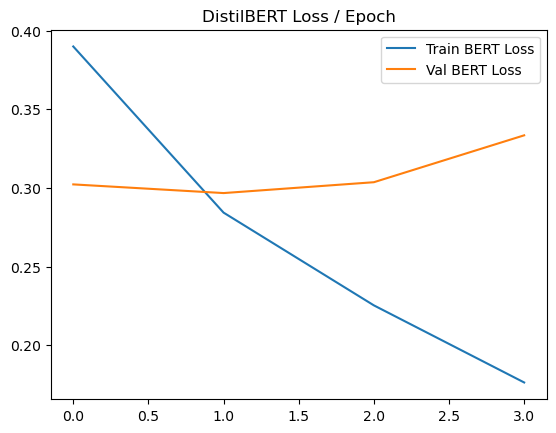

In [21]:
plt.plot(base_model.history['loss'], label='Train BERT Loss')
plt.plot(base_model.history['val_loss'], label='Val BERT Loss')
plt.title('DistilBERT Loss / Epoch')
plt.legend()

### 3. Model evaluation

In [22]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, val_data, batch_size=32, threshold=0.5):
    # Unpack validation data
    X_val_, y_val_ = val_data

    # If labels are one-hot encoded, convert to 1D
    if y_val_.ndim == 2 and y_val_.shape[1] == 2:
        y_val_ = np.argmax(y_val_, axis=1)

    # Predictions
    val_predictions = model.predict(X_val_, batch_size=batch_size)

    # Handle softmax vs sigmoid outputs
    if val_predictions.ndim == 2 and val_predictions.shape[1] == 2:
        # Softmax case: pick highest probability
        val_pred_classes = np.argmax(val_predictions, axis=1)
        # For ROC-AUC, use probability of positive class
        val_predictions = val_predictions[:, 1]
    else:
        # Sigmoid case: threshold at 0.5
        val_pred_classes = (val_predictions > threshold).astype(int).flatten()
        val_predictions = val_predictions.flatten()

    # True labels
    true_labels = y_val_

    # Ensure lengths match
    val_pred_classes = val_pred_classes[:len(true_labels)]
    val_predictions = val_predictions[:len(true_labels)]

    # Metrics
    metrics = {
        "accuracy": accuracy_score(true_labels, val_pred_classes),
        "precision": precision_score(true_labels, val_pred_classes),
        "recall": recall_score(true_labels, val_pred_classes),
        "f1": f1_score(true_labels, val_pred_classes),
        "roc_auc": roc_auc_score(true_labels, val_predictions)
    }

    for k, v in metrics.items():
        print(f"{k.capitalize()}: {v:.4f}")

    return metrics

In [23]:
# Usage
val_data = (X_test, y_test)
baseline_result = evaluate_model(classifier, val_data)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1139s 2s/step
Accuracy: 0.8787
Precision: 0.8817
Recall: 0.8748
F1: 0.8783
Roc_auc: 0.9490


baseline model perform pretty good using Keras_hub library, we will tune to a comparable model using upgraded keras_npl library with some adjustment to understand which elements are driving result

### 4.1 train with keras npl using loss function for multi class

In [24]:
import keras_nlp

In [25]:
# MODEL ARCHITECT:

preset= "distil_bert_base_en_uncased"

# Use a shorter sequence length.
preprocessor_ = keras_nlp.models.DistilBertPreprocessor.from_preset(preset,
                                                                   sequence_length=128, 
                                                                   name="preprocessor_4_review"
                                                                  )

# Pretrained classifier.
classifier_npl = keras_nlp.models.DistilBertClassifier.from_preset(preset,
                                                               preprocessor = preprocessor_, 
                                                               num_classes=2) 

classifier_npl.summary()

Preprocessor: "preprocessor_4_tweets"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,955,010 (255.41 MB)

 Trainable params: 66,955,010 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
from tensorflow import keras

In [27]:
# TRAIN WITH KERAS_NPL --use same set of training/validation of baseline model to compare result

classifier_npl.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='adam', metrics=["accuracy"]) #use different loss

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Fit on same set from keras_hub model
model_npl = classifier_npl.fit(x=X_train.values, y=y_train.values,
                             batch_size=32,
                             epochs=10, 
                             validation_data=(X_val, y_val),
                             callbacks=[early_stop]
                            )


Epoch 1/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 14940s 17s/step - accuracy: 0.4969 - loss: 0.6951 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 22448s 26s/step - accuracy: 0.4989 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 9497s 11s/step - accuracy: 0.4955 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 5465s 6s/step - accuracy: 0.4988 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 28095s 32s/step - accuracy: 0.4942 - loss: 0.6940 - val_accuracy: 0.5000 - val_loss: 0.6933


thanks to early stopping we prevent losing time when no improvement.

### 4.2 training with keras hub using loss function for binary class

In [28]:
# update loss function
classifier_npl2 = keras_nlp.models.DistilBertClassifier.from_preset(preset,
                                                               preprocessor = preprocessor_, 
                                                               num_classes=1) #1 update loss function, change the class to 1

classifier_npl2.summary()

Preprocessor: "preprocessor_4_tweets"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 1)                 │             769 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,954,241 (255.41 MB)

 Trainable params: 66,954,241 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
#train updated loss function model, everything else same
classifier_npl2.compile(loss=BinaryCrossentropy(from_logits=True), optimizer='adam', metrics=["accuracy"])

# Fit on same set from keras_hub model
model_npl2 = classifier_npl2.fit(x=X_train.values, y=y_train.values,
                             batch_size=32,
                             epochs=10, 
                             validation_data=(X_val, y_val),
                             callbacks=[early_stop]
                            )

Epoch 1/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 8051s 9s/step - accuracy: 0.4997 - loss: 0.6951 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 12607s 14s/step - accuracy: 0.5000 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6932


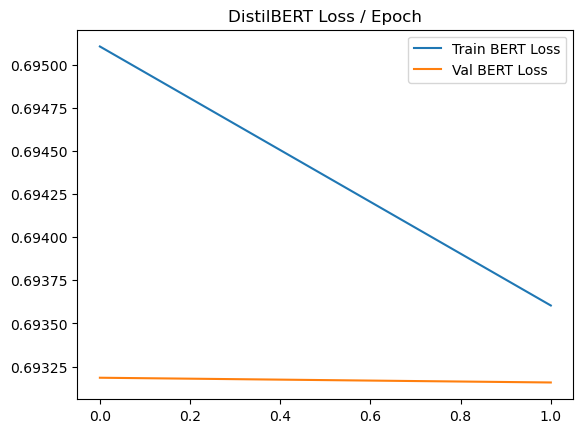

In [35]:
plt.plot(model_npl2.history['loss'], label='Train BERT Loss')
plt.plot(model_npl2.history['val_loss'], label='Val BERT Loss')
plt.title('DistilBERT Loss / Epoch')
plt.legend()

# IV) Results and Analysis

as we use alternative model above without performance improvement, we will finetuning the baseline model by update text processing.

### 1. Model enhancement
In previous text processing, we trained model using text refining by stop_words, which remove common words and expect remaining only identical words to the sentiment only.
In this enhancement, we will use spacy function, to convert the text to it original form, such as makes or made or making to be 'make' and so on. By this approach, we expect to keep the most raw format of sentence and predict after vectorization such "processing text".

In [30]:
#refining text function
import spacy
# Preprocess our text setup
nlp = spacy.load('en_core_web_sm')

def preprocess(txt):
    doc = nlp(txt.lower())
    return ' '.join([token.lemma_ for token in doc if token.is_alpha and not token.is_stop])

df['text_clean2'] = df['review'].apply(preprocess)

df['text_clean2']

0        reviewer mention watch oz episode hook right exactly happen thing strike oz brutality unflinche scene violence set right word trust faint hearted timid pull punch regard drug sex violence hardcore classic use call oz nickname give oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inward privacy high agenda em city home aryan muslim gangsta latinos christians italian irish scuffle death stare dodgy dealing shady agreement far main appeal fact go show dare forget pretty picture paint mainstream audience forget charm forget romance oz mess episode see strike nasty surreal ready watch develop taste oz get accustomed high level graphic violence violence injustice crooked guard sell nickel inmate kill order away mannered middle class inmate turn prison bitch lack street skill prison experience watch oz comfortable uncomfortable viewing that touch dark
1                                                                

In [31]:
X_temp, X_test, y_temp, y_test = train_test_split(df['text_clean2'], df['class'], test_size=0.3, stratify=df['class']) #saving 15k records for testing
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp) #28k records for training and 7k for valiation

In [32]:
optimized_model = classifier.fit(x=X_train.tolist(), y=y_train.astype('float32').values, 
               validation_data=(X_val.tolist(), y_val.astype('float32').values), 
               batch_size=32, epochs=10, callbacks=[early_stop])

Epoch 1/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 28504s 32s/step - accuracy: 0.8750 - loss: 0.2846 - val_accuracy: 0.8890 - val_loss: 0.2595
Epoch 2/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 7395s 8s/step - accuracy: 0.8994 - loss: 0.2380 - val_accuracy: 0.8919 - val_loss: 0.2603
Epoch 3/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 10370s 12s/step - accuracy: 0.9265 - loss: 0.1850 - val_accuracy: 0.8914 - val_loss: 0.2777


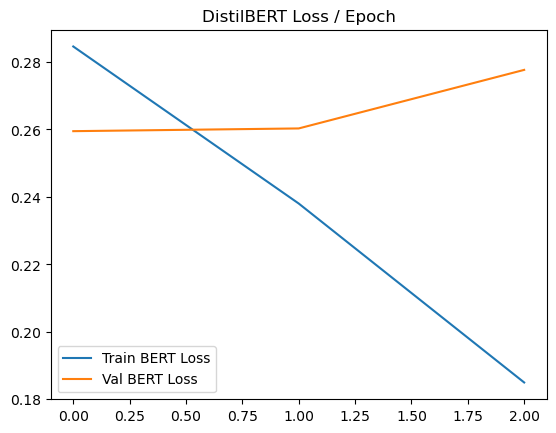

In [33]:
plt.plot(optimized_model.history['loss'], label='Train BERT Loss')
plt.plot(optimized_model.history['val_loss'], label='Val BERT Loss')
plt.title('DistilBERT Loss / Epoch')
plt.legend()

### 2. Model evaluation

In [34]:
val_data2 = (X_test, y_test)
optimized_result = evaluate_model(classifier, val_data2)

469/469 ━━━━━━━━━━━━━━━━━━━━ 7745s 17s/step
Accuracy: 0.8807
Precision: 0.9102
Recall: 0.8448
F1: 0.8763
Roc_auc: 0.9544


AUC ROC score looks better than baseline model 

# V) Conclusion 



From result of baseline model and hyper model, we can see major step can help to improve model performance as following:
1) process of text cleaning place an important role for model training, if training text is not carefully handle, poluted data made model learning very ineffective. Result proven in baseline model submit reach 0.9490 ROC_AUC score but in new approach, score improve to 0.9544 on test set.
2) suggest using spacy.load('en_core_web_sm') for text cleaning is more effective for model prediction, rather than using text cleaning by stop_words library although with customized enrichment. However, using this approach will cost more time for text conversion.
3) library using for model training also place significant impact on model prediction result. Despite same number of parameter, the core function and respective algorithm inside the applied library place key role to boost model performance, i.e keras_npl process less efficient vs. keras_hub
4) early stop is important to manage efficiency, avoid wasting time on additional epoch without significant improvement
5) loss function play important role in model training, for purpose of binary classify, use loss function BinaryCrossentropy with activation function using Sigmoid help model perform better than SparseCategoricalCrossentropy using activation function Softmax --which is more suitable for classify multiple classes.

**Future work**
some further work can be done: 
1) try 3 different learning rate to test model's efficient.
2) using AdamW as optimizer vs. Adam to generalize model to reduce overfitting effect.

# VI) Produce Deliverables: High-Quality, Organized Jupyter Notebook Report, GitHub Repository, and screenshot of Kaggle leaderboard 




### This work inspired by these references:
1. Stopword List : https://github.com/6/stopwords-json/blob/master/dist/en.json
2. Keras https://keras.io/guides/keras_nlp/getting_started/
3. keras_hub: https://keras.io/keras_hub/presets/
4. dataset: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/data

### Github link: 
https://github.com/GabyVothy/DeepLearning/blob/main/NPL%20project_submit.ipynb